# Pm10 Modelling

## Phase 1

In [29]:
import pandas as pd

# Load the CSV sample file
file_path = 'LAEI-2019-Emissions-Summary-including-Forecast/2019filteredatacsv.csv'
df = pd.read_csv(file_path)

# Step 1: View dataset structure
print("=== Data Overview ===")
print(df.info())
print(df.head())

# Step 2: Check for missing values
print("\n=== Missing Values ===")
print(df.isnull().sum())

# Step 3: Unique values for categorical inspection
print("\n=== Unique Values per Column ===")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

# Step 4: Basic statistics
print("\n=== Descriptive Statistics ===")
print(df.describe(include='all'))

=== Data Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143976 entries, 0 to 143975
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Year                  143976 non-null  int64  
 1   Grid ID 2019          143976 non-null  int64  
 2   LAEI 1km2 ID          143976 non-null  int64  
 3   Easting               143976 non-null  int64  
 4   Northing              143976 non-null  int64  
 5   Borough               143976 non-null  object 
 6   Zone                  143976 non-null  object 
 7   Main Source Category  143976 non-null  object 
 8   Sector                143976 non-null  object 
 9   Source                143976 non-null  object 
 10  bap                   31140 non-null   float64
 11  cd                    17300 non-null   float64
 12  c4h6                  34600 non-null   float64
 13  c6h6                  44980 non-null   float64
 14  ch4                   51900 no

In [33]:
# Reload the full dataset for cleaning
file_path = 'LAEI-2019-Emissions-Summary-including-Forecast/2019filteredatacsv.csv'
df = pd.read_csv(file_path)

# Step 1: Drop unnecessary or low-value columns
drop_columns = [
    'Year', 'Grid ID 2019', 'LAEI 1km2 ID',
    'bap', 'cd', 'c4h6', 'c6h6', 'ch4', 'co', 'hc', 'hcl', 'hg', 'n2o',
    'nh3', 'nmvoc', 'pb', 'pcb', 'so2', 'Emissions Unit'
]
df.drop(columns=drop_columns, inplace=True)

# Step 2: Label encode categorical features
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Borough', 'Zone', 'Main Source Category', 'Sector', 'Source']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le  # Save for inverse transformation later

print("Data cleaned and encoded.")
print(df.head())

# Step 3: Show the cleaned and encoded DataFrame
df.to_csv("LAEI2019_Cleaned.csv", index=False)
print("Cleaned data saved to 'LAEI2019_Cleaned.csv'")

Data cleaned and encoded.
   Easting  Northing  Borough  Zone  Main Source Category  Sector  Source  \
0   532500    181500        6     0                     4      14      36   
1   532500    181500       19     0                     4      14      36   
2   530500    181500        5     0                     4      14      36   
3   531500    179500       29     0                     4      14      36   
4   531500    179500       29     1                     4      14      36   

           co2       nox      pm10     pm2.5  
0   801.702422  0.815941  0.202529  0.090511  
1    96.064233  0.146172  0.030548  0.013716  
2  1654.324756  1.342779  0.398525  0.177336  
3  1307.588067  0.933334  0.309936  0.137778  
4   268.764076  0.225646  0.050658  0.022702  
Cleaned data saved to 'LAEI2019_Cleaned.csv'


## Phase 2

In [34]:
# Load cleaned dataset
df = pd.read_csv("LAEI2019_Cleaned.csv")

# Preview missing data in NOx and CO2
print("Missing NOx:", df['nox'].isnull().sum())
print("Missing CO2:", df['co2'].isnull().sum())

# Quick preview of data structure
print(df.info())
df.head()

Missing NOx: 20760
Missing CO2: 31140
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143976 entries, 0 to 143975
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Easting               143976 non-null  int64  
 1   Northing              143976 non-null  int64  
 2   Borough               143976 non-null  int64  
 3   Zone                  143976 non-null  int64  
 4   Main Source Category  143976 non-null  int64  
 5   Sector                143976 non-null  int64  
 6   Source                143976 non-null  int64  
 7   co2                   112836 non-null  float64
 8   nox                   123216 non-null  float64
 9   pm10                  140516 non-null  float64
 10  pm2.5                 140516 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 12.1 MB
None


,Easting,Northing,Borough,Zone,Main Source Category,Sector,Source,co2,nox,pm10,pm2.5
0,532500,181500,6,0,4,14,36,801.702422,0.815941,0.202529,0.090511
1,532500,181500,19,0,4,14,36,96.064233,0.146172,0.030548,0.013716
2,530500,181500,5,0,4,14,36,1654.324756,1.342779,0.398525,0.177336
3,531500,179500,29,0,4,14,36,1307.588067,0.933334,0.309936,0.137778
4,531500,179500,29,1,4,14,36,268.764076,0.225646,0.050658,0.022702


In [35]:
from sklearn.ensemble import RandomForestRegressor

# Load cleaned dataset
df = pd.read_csv("LAEI2019_Cleaned.csv")

# Step 2.1: Define features and target for NOx
features = ['co2', 'pm10', 'pm2.5', 'Borough', 'Zone', 'Main Source Category', 'Sector', 'Source', 'Easting', 'Northing']
target = 'nox'

# Step 2.2: Split into rows with known and missing NOx
nox_known = df[df['nox'].notnull()]
nox_missing = df[df['nox'].isnull()]

# Step 2.3: Prepare training data
X_train_nox = nox_known[features]
y_train_nox = nox_known[target]

# Step 2.4: Prepare prediction data
X_pred_nox = nox_missing[features]

# Step 3.1: Train the Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

nox_model = RandomForestRegressor(n_estimators=100, random_state=42)
nox_model.fit(X_train_nox, y_train_nox)

# Step 3.2: Predict missing NOx values
nox_predictions = nox_model.predict(X_pred_nox)

# Step 3.3: Fill in the predicted values
df.loc[df['nox'].isnull(), 'nox'] = nox_predictions

print(" Missing NOx values imputed:", len(nox_predictions))
# Step 1: Define features and target for CO2
features_co2 = ['nox', 'pm10', 'pm2.5', 'Borough', 'Zone', 'Main Source Category', 'Sector', 'Source', 'Easting', 'Northing']
target_co2 = 'co2'

# Step 2: Split into known and missing
co2_known = df[df['co2'].notnull()]
co2_missing = df[df['co2'].isnull()]

# Step 3: Prepare training data
X_train_co2 = co2_known[features_co2]
y_train_co2 = co2_known[target_co2]

# Step 4: Drop rows where predictors are still missing
X_pred_co2 = co2_missing[features_co2].dropna()
rows_to_fill = X_pred_co2.index  # store the index to match back

# Train and predict
co2_model = RandomForestRegressor(n_estimators=100, random_state=42)
co2_model.fit(X_train_co2, y_train_co2)
co2_predictions = co2_model.predict(X_pred_co2)

# Fill only the rows we could predict
df.loc[rows_to_fill, 'co2'] = co2_predictions

print("Imputed CO2 values:", len(co2_predictions))
df.to_csv("LAEI2019_Final_Imputed.csv", index=False)

 Missing NOx values imputed: 20760
Imputed CO2 values: 27680


## WHO Threshold Breach Hotspot Map

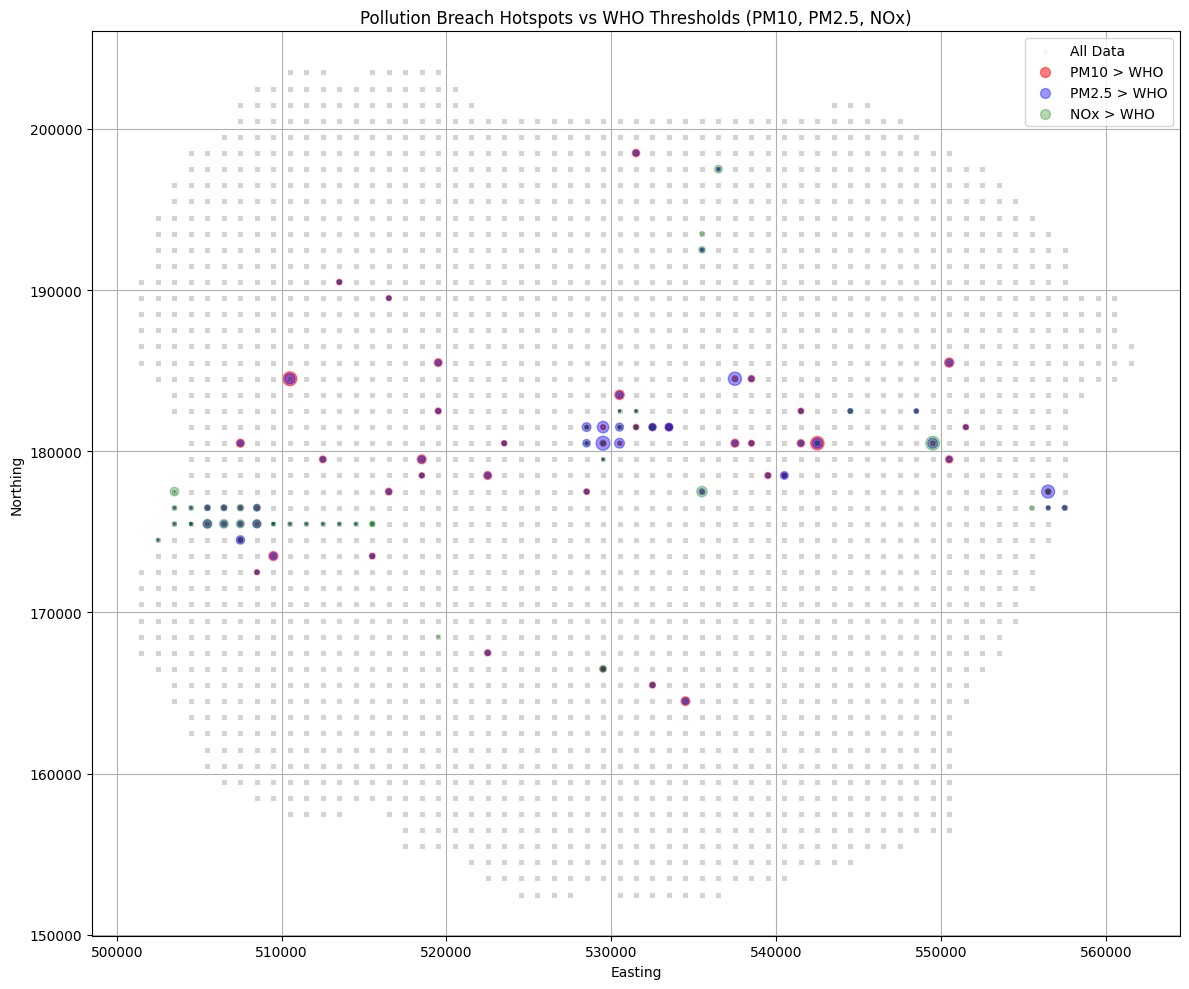

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset (adjust path if needed)
df = pd.read_csv("LAEI2019_Final_Imputed.csv")

# Define WHO thresholds
who_thresholds = {
    'pm10': 15,
    'pm2.5': 5,
    'nox': 40,
}

# Select relevant columns
df_subset = df[['Easting', 'Northing', 'pm10', 'pm2.5', 'nox']]

# Filter rows where any pollutant exceeds WHO threshold
breach_df = df_subset[
    (df_subset['pm10'] > who_thresholds['pm10']) |
    (df_subset['pm2.5'] > who_thresholds['pm2.5']) |
    (df_subset['nox'] > who_thresholds['nox'])
]

# Plot all data in background
plt.figure(figsize=(12, 10))
plt.scatter(df_subset['Easting'], df_subset['Northing'],
            s=5, color='lightgrey', alpha=0.2, label='All Data')

# Plot PM10 breaches
plt.scatter(breach_df['Easting'], breach_df['Northing'],
            s=breach_df['pm10'] / df_subset['pm10'].max() * 100,
            color='red', alpha=0.5, label='PM10 > WHO')

# Plot PM2.5 breaches
plt.scatter(breach_df['Easting'], breach_df['Northing'],
            s=breach_df['pm2.5'] / df_subset['pm2.5'].max() * 100,
            color='blue', alpha=0.4, label='PM2.5 > WHO')

# Plot NOx breaches
plt.scatter(breach_df['Easting'], breach_df['Northing'],
            s=breach_df['nox'] / df_subset['nox'].max() * 100,
            color='green', alpha=0.3, label='NOx > WHO')

# Final styling
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.title("Pollution Breach Hotspots vs WHO Thresholds (PM10, PM2.5, NOx)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
